Universidad Central de Venezuela <br>
Facultad de Ciencias <br>
Escuela de Computación <br>
Minería de Datos <br>
Profesor: Wilmer González <br>
Estudiante: Yarima Contreras. C.I.: V-29.706.291 <br>

# <center> Asignación 2: </center>
## <center> EDA de "Credit Card Dataset for Clustering" </center>

Para iniciar el análisis exploratorio, se realiza la importación de la librería Pandas, permitiéndonos realizar primero una previsualización de los datos del dataset asignado (https://www.kaggle.com/datasets/arjunbhasin2013/ccdata):

In [29]:
import pandas as pd

PATH_DATA = r"./CreditCardDatasetForClustering.csv"
df = pd.read_csv(PATH_DATA)

<strong>1) Descripción del Dataset</strong>
<br>
Para reportar la cantidad de filas, columnas y tipos de datos, se utilizan las funciones de len para las filas, shape para las columnas, y los tipos de datos pueden ser respondidos observando los dtypes. De esta forma, se aprecia lo siguiente:

In [30]:
# Dimensiones del dataset
print(f"Total de filas: {len(df)}")
print(f"Total de columnas: {df.shape[1]}")

# Tipo de dato de cada columna
print(f"\nTipos de datos:")
for col, dtype in df.dtypes.items():
    print(f"* {col}: {dtype}")

# Adicional: Previsualización de la data
print(f"\nPrevisualización de los datos:")
df

Total de filas: 8950
Total de columnas: 18

Tipos de datos:
* CUST_ID: object
* BALANCE: float64
* BALANCE_FREQUENCY: float64
* PURCHASES: float64
* ONEOFF_PURCHASES: float64
* INSTALLMENTS_PURCHASES: float64
* CASH_ADVANCE: float64
* PURCHASES_FREQUENCY: float64
* ONEOFF_PURCHASES_FREQUENCY: float64
* PURCHASES_INSTALLMENTS_FREQUENCY: float64
* CASH_ADVANCE_FREQUENCY: float64
* CASH_ADVANCE_TRX: int64
* PURCHASES_TRX: int64
* CREDIT_LIMIT: float64
* PAYMENTS: float64
* MINIMUM_PAYMENTS: float64
* PRC_FULL_PAYMENT: float64
* TENURE: int64

Previsualización de los datos:


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


Con esta primera inspección se puede apreciar que el dataset posee 8950 filas y 18 columnas, de las cuales 14 son valores flotantes (float64), lo que indica que el dataset está compuesto principalmente por variables cuantitativas continuas, lo cual concuerda con el contexto del mismo (tarjetas de crédito). Adicionalmente, el 'CUST_ID' es de tipo object debido a que se trata de un dato alfanumérico.

<strong>2) Estadísticas Descriptivas</strong>
<br>
A continuación, se muestra un resumen de descriptores estadísticos relevantes, tales como la media, mediana, desviación estándar, mínimo y máximo para variables numéricas.

In [31]:
# Selección de columnas numéricas
df_numeric = df.select_dtypes(include=['number'])

# Resumen estadístico base, transponiendo variables a filas
desc_stats = df_numeric.describe().T

# Organización del reporte
final_report = desc_stats[['mean', '50%', 'std', 'min', 'max']].rename(
    columns={
        'mean': 'Media',
        '50%': 'Mediana',
        'std': 'Desviación Estándar',
        'min': 'Mínimo',
        'max': 'Máximo'
    }
)

print("Estadísticas Descriptivas")
print(final_report)

Estadísticas Descriptivas
                                        Media      Mediana  \
BALANCE                           1564.474828   873.385231   
BALANCE_FREQUENCY                    0.877271     1.000000   
PURCHASES                         1003.204834   361.280000   
ONEOFF_PURCHASES                   592.437371    38.000000   
INSTALLMENTS_PURCHASES             411.067645    89.000000   
CASH_ADVANCE                       978.871112     0.000000   
PURCHASES_FREQUENCY                  0.490351     0.500000   
ONEOFF_PURCHASES_FREQUENCY           0.202458     0.083333   
PURCHASES_INSTALLMENTS_FREQUENCY     0.364437     0.166667   
CASH_ADVANCE_FREQUENCY               0.135144     0.000000   
CASH_ADVANCE_TRX                     3.248827     0.000000   
PURCHASES_TRX                       14.709832     7.000000   
CREDIT_LIMIT                      4494.449450  3000.000000   
PAYMENTS                          1733.143852   856.901546   
MINIMUM_PAYMENTS                   864.20654

Al obtener estos resultados, se pueden encontrar distintas características, tales como:

* Sesgo Positivo (Skewness): Al observar la media y mediana, se puede ver que casi todas las variables financieras (como 'BALANCE', 'PURCHASES', 'CASH_ADVANCE' y 'PAYMENTS') muestran un sesgo a la derecha. En 'BALANCE' el valor de la media es casi el doble del de la mediana. Esto puede indicar que la mayoría de los usuarios poseen saldos y consumos moderados, pero existen algunos usuarios con consumos altos que ocasionan el aumento del promedio.

* Alta Dispersión: Hay muchos valores de desviación estándar altos. Por ejemplo, en la variable 'PURCHASES' se tiene que la desviación es mayor que la media. Esto parece mostrar que no hay un comportamiento típico. Al observar el mínimo y máximo, se tiene que el rago es de 0 a 49039.57, mostrando que hay usuarios que no compran nada y otros que tienen altos gastos.

<strong>3) Valores Faltantes</strong>
<br>
Ahora, es importante identificar la cantidad de valores nulos por columna. Para ello, se ejecuta el siguiente fragmento de código:

In [32]:
null_values = df.isnull().sum()

print("Cantidad de valores faltantes por columna:")
print(null_values)

# Adicional: Porcentaje de valores faltantes
print("\nAdicionalmente, se muestra el porcentaje de valores faltantes:")
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
print(porcentaje_nulos)

Cantidad de valores faltantes por columna:
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Adicionalmente, se muestra el porcentaje de valores faltantes:
CUST_ID                             0.000000
BALANCE                             0.000000
BALANCE_FREQUENCY                   0.000000
PURCHASES                

Con esta inspección, se puede apreciar que en términos de valores faltantes, la calidad del dataset es muy buena. El campo con más vacíos es 'MINIMUN_PAYMENTS', con 313 valores nulos, no obstante, esa cantidad representa un 3.49% del total, de modo que no es significativo ni perjudica al resto de datos.

<strong>4) Histogramas</strong>
<br>
Para continuar, se representa visualmente la distribución de datos de las variables 'BALANCE', 'PURCHASES' y 'TENURE'.

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\yarim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


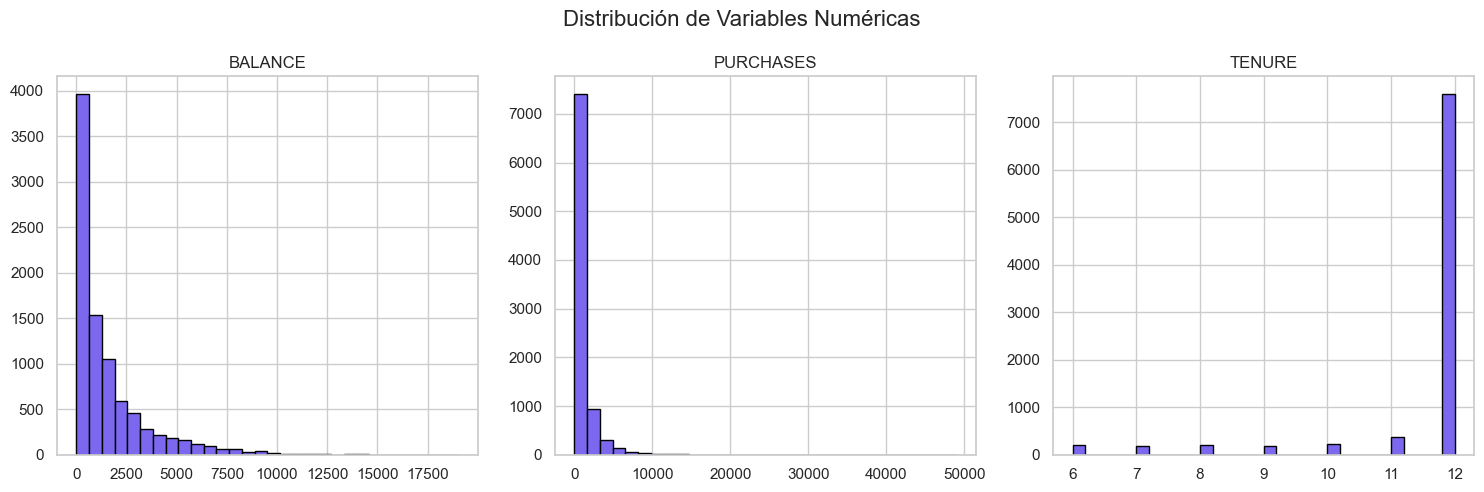

In [33]:
# Instalación de matplotlib para visualización
!pip install matplotlib
import matplotlib.pyplot as plt

# Variables de interés
variables = ['BALANCE', 'PURCHASES', 'TENURE']

# Creación de los histogramas
df[variables].hist(bins=30, figsize=(15, 5), layout=(1, 3), color='mediumslateblue', edgecolor='black')

# Organización
plt.suptitle('Distribución de Variables Numéricas', fontsize=16)
plt.tight_layout()
plt.show()

Con la realización de estos tres histogramas, se pueden realizar las siguientes observaciones:

* 'BALANCE' y 'PURCHASES' poseen asimetría positiva, debido a que presentan una cola larga hacia la derecha. Como se expresó anteriormente, la mayoría de los clientes mantienen saldos y gastos bajos, pero una minoría posee alto consumo que ocasionan que la media se desplace.

* 'TENURE' posee asimetría negativa y los datos se amontonan en el valor máximo. Esto indica que la mayoría de los usuarios han permanecido todo el año con la tarjeta de crédito.

<strong>5) Box Plots</strong>
<br>
Para identificar valores anómalos, se han seleccionado las variables 'PAYMENTS' y 'CREDIT_LIMIT' debido a que son las que presentan una desviación estándar más grande.

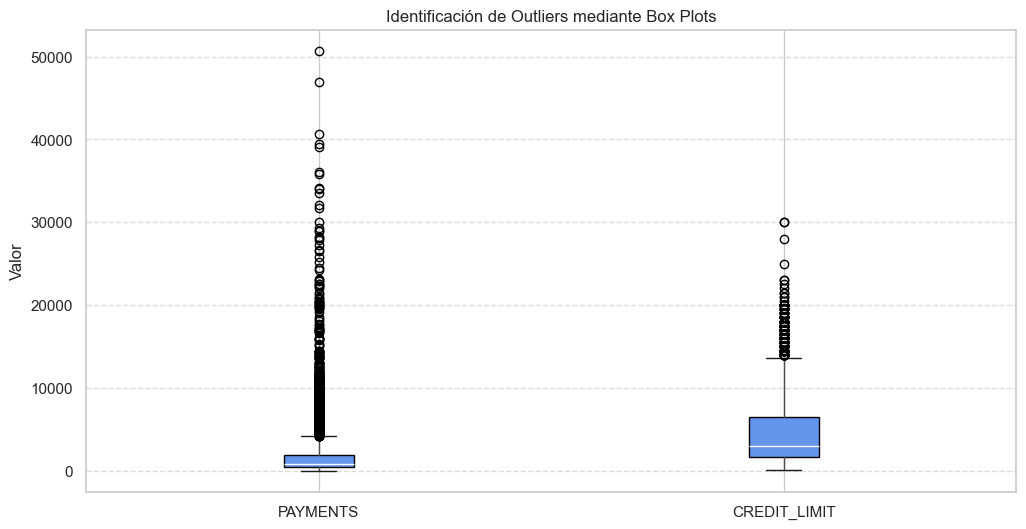

In [34]:
# Variables de interés
variables_boxplot = ['PAYMENTS', 'CREDIT_LIMIT']

# Creación de la figura para los boxplots
plt.figure(figsize=(12, 6))

# Creación de los boxplots
df[variables_boxplot].boxplot(patch_artist=True, 
                               boxprops=dict(facecolor='cornflowerblue', color='black'),
                               medianprops=dict(color='white'))

plt.title('Identificación de Outliers mediante Box Plots')
plt.ylabel('Valor')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

La implementación de Box Plots permite confirmar las sospechas que se habían comentado en los puntos anteriores:

* En ambas variables se observa una cantidad considerable de puntos por encima del "bigote" superior. Esto indica que existen usuarios con pagos y límites de crédito que se escapan del promedio del grupo.

* La caja de 'CREDIT_LIMIT' es un poco más grande que la de 'PAYMENTS', esto señala que existe una mayor dispersión en los límites de crédito asignados que en los pagos realizados por los usuarios.

* Por su parte, 'PAYMENTS' muestra valores atípimos muy altos, considerando que la concentración de datos de esta variable es más cercana al cero. Esto puede explicar el el sesgo positivo que se ha identificado antes.

<strong>6) Análisis de Correlación</strong>
<br>
Teniendo la evidencia de la existencia de valores anómalos, se implementa una matriz de correlación como Heatmap y un Scatter Plot del par de variables con mayor correlación.
Para iniciar la observación, se toman en cuenta variables respectivas a las deudas, compras, pagos y límite de crédito, ya que se consideran de interés principal para saber el comportamiento de los usuarios portadores de tarjetas de crédito.

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\yarim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


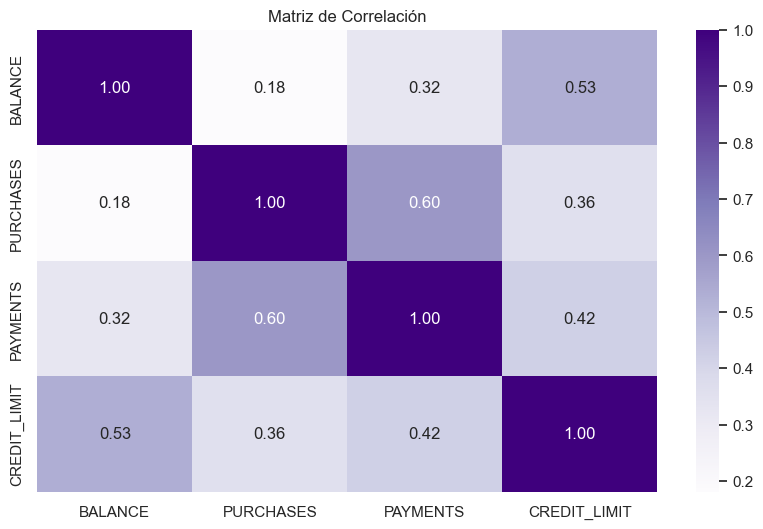

In [35]:
# Instalación de seaborn para facilitar la matriz de correlación
!pip install seaborn
import seaborn as sns

# Matriz de correlación (Heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(df[['BALANCE', 'PURCHASES', 'PAYMENTS', 'CREDIT_LIMIT']].corr(), 
            annot=True, cmap='Purples', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

Visualizando la matriz resultante, se puede concluir que:

* La correlación más fuerte se da entre 'PURCHASES' y 'PAYMENTS' indicando que los clientes que más consumen son aquellos que más deben pagar a la cuenta. Eso una relación lógica, debido a que la dinámica de las tarjetas de crédito consiste en utilizar el dinero proporcionado y luego cancelar la deuda. Por esta razón, el interés recae en que el valor no es 1.00 directamente, esto puede indicar que los usurios no cancelan sus deudas de inmediato, sino que tienden a acumularlas.

* Otra correlación un poco menos fuerte se da entre 'BALANCE' y 'CREDIT_LIMIT'. Esto muestra que los usuarios con límites de crédito más altos tienden a mantener saldos más elevados. Es coherente ya que el banco les da más cupo y ellos lo utilizan.

* Por otro lado, se puede apreciar que 'BALANCE' y 'PURCHASES' tienen una relación débil, señalando entonces que tener un saldo alto no implica que el usuario esté comprando mucho. Puede ser un caso de deudas anteriores, ya que se pudo apreciar en la primera correlación que estas deudas no son saldadas inmediatamente.

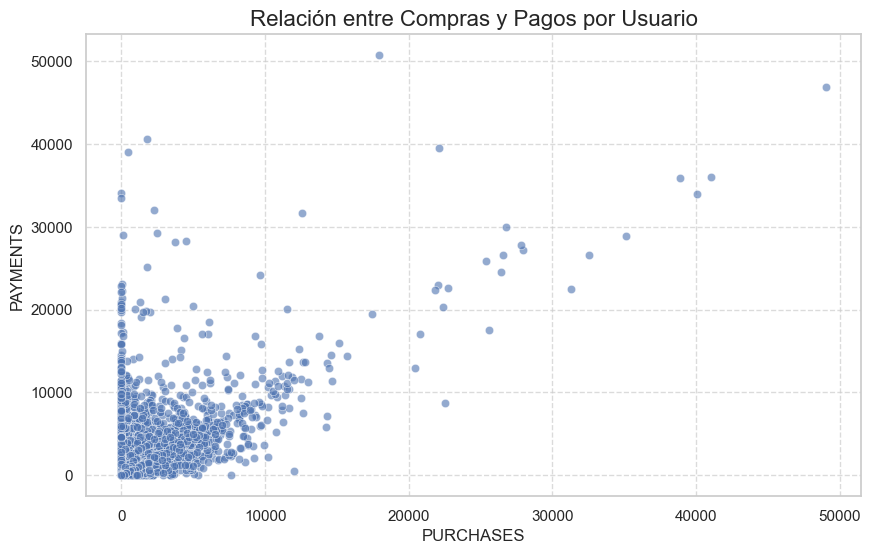

In [36]:
# Estilo de Seaborn
sns.set_theme(style="whitegrid")

# Creación del Scatter Plot (gráfico de dispersión)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PURCHASES', y='PAYMENTS', 
                sizes=(20, 400),
                alpha=0.6)

plt.title('Relación entre Compras y Pagos por Usuario', fontsize=16)
plt.xlabel('PURCHASES', fontsize=12)
plt.ylabel('PAYMENTS', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

Con base en el gráfico obtenido, se pueden realizar los siguientes comentarios:

* Los puntos tienen una inclinación ascendente a la derecha. Esto confirma la tendencia de que si un usuario realiza más compras, también debe realizar mayores pagos.

* La mayor densidad se halla cerca del valor (0, 0), esto refuerza lo encontrado en los histogramas anteriores, donde se observó que la mayoría de los usuarios son de bajo consumo.

* Hay puntos bastante alejados del resto, que concuerdan con los movimientos de alto consumo. Por tanto, estos son los valores reflejados en la sección de valores atípicos.

* La forma de los puntos también confirma la correlación de 0.6 conseguida anteriormente. Muchos usuarios mantienen un comportamiento de realizar compras que no pagan en la misma proporción durante el lapso correspondiente. Asimismo, hay bastantes casos de pagos con pocas compras, lo que parece indicar la presencia de abonos a deudas acumuladas desde antes.

Habiendo hecho esta primera observación de correlación con las variables de interés, se plantea una segunda matriz, esta vez considerando todas las variables de tipo numérico. En esta ocasión el objetivo es encontrar correlaciones que hayan sido pasadas por alto con el primer enfoque.

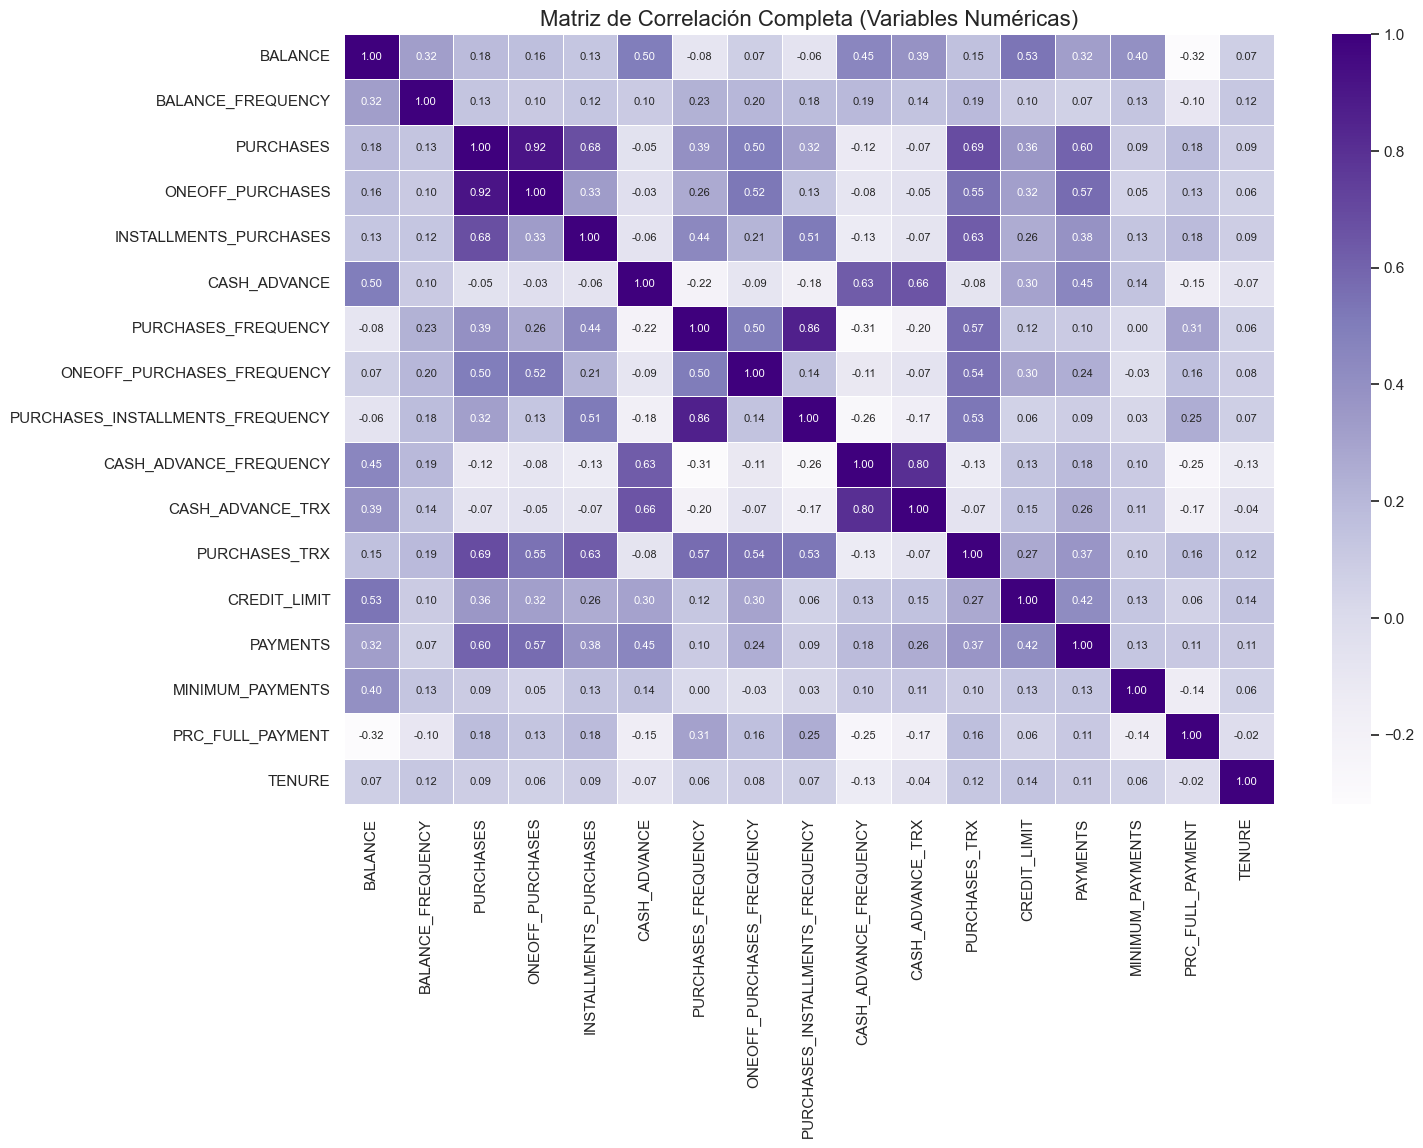

In [37]:
corr_full = df_numeric.corr() # Cálculo de la matriz de correlación para todas las variables numéricas

# 3. Graficamos
plt.figure(figsize=(15, 10))
sns.heatmap(corr_full, 
            annot=True,
            cmap='Purples',
            fmt=".2f",
            linewidths=0.5,
            annot_kws={"size": 8})

plt.title('Matriz de Correlación Completa (Variables Numéricas)', fontsize=16)
plt.show()

Teniendo este segundo Heatmap, se observa una correlación mucho más fuerte: 'PURCHASES' y 'ONEOFF_PURCHASES'. Dado que este valor es de 0.92, se interpreta que las compras de los usuarios se tratan casi exclusivamente de compras únicas. Es decir, que la mayoría de estos no usan la tarjeta para cuotas pequeñas o repetitivas, sino que realizan transacciones grandes y únicas.

Otras relaciones relevantes por su alta o baja correlación son las siguientes:

* 'PURCHASES_FREQUENCY' y 'PURCHASES_INSTALLMENTS_FREQUENCY' poseen una correlación de 0.86. Esto parece indicar que los clientesque compran con frecuencia lo hacen utilizando planes de cuotas.

* 'PCR_FULL_PAYMENT' y 'BALANCE' es una de las pocas correlaciones negativas presentes (-0.32). Esto indica que las variables poseen una relación inversamente proporcional, la cual se explica como que si la deuda acumulada (el balance) aumenta, entonces el porcentaje de pagos totales (el pcr_full_payment) tiende a disminuir. Leyéndolo de forma inversa, se entiende que los usuarios que tienen deudas más bajas son los que logran pagar su deuda completamente.

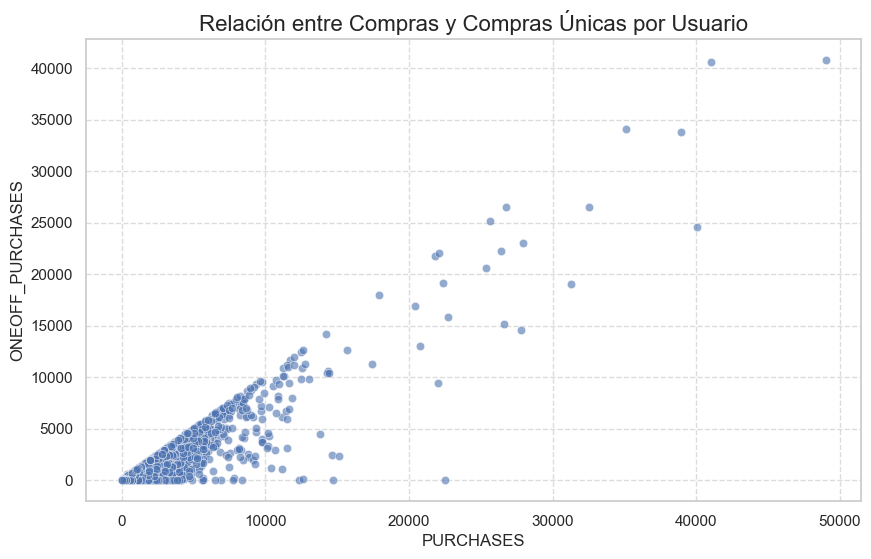

In [38]:
# Estilo de Seaborn
sns.set_theme(style="whitegrid")

# Creación del Scatter Plot (gráfico de dispersión)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PURCHASES', y='ONEOFF_PURCHASES', 
                sizes=(20, 400),
                alpha=0.6)

plt.title('Relación entre Compras y Compras Únicas por Usuario', fontsize=16)
plt.xlabel('PURCHASES', fontsize=12)
plt.ylabel('ONEOFF_PURCHASES', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

Por último, se realiza el Scatter Plot con las variables de mayor correlación, es decir, 'PURCHASES' y 'ONEOFF_PURCHASES'. En este gráfico se puede apreciar que, a diferencia del anterior, que era más disperso, este parece formar una línea más definida. Así, esta línea muestra que para esos casos, el gasto realizado fue una compra única.

Con estas conclusiones, se da por finalizado el Análisis Exploratorio de Datos solicitado.